# 示例 1：买入持有（沪深300ETF，510300.SH）

最朴素的策略：回测首日满仓买入沪深300ETF（510300.SH），之后一直持有、不再操作。

用它演示 xxybacktest 的**最小可用回测骨架**，以及「基金」（asset_type='fund'）数据怎么用。

**运行说明**

- 数据：仓库内置 `./data`（全市场 2020 上半年，股票 + 基金）
- 内核：请选择带 `xxybacktest` 依赖的 Python 内核（如本机注册的 `xxybacktest (vnpy)` 环境）。
- 操作：在仓库根目录打开本 notebook，「重启内核并运行所有单元格」即可。
- 回测曲线、回撤与绩效指标表会在最后一个代码单元格运行后自动显示（图已预执行嵌入，离线打开也能直接看）。

In [1]:
%matplotlib inline
from xxybacktest import run_backtest

In [2]:
CODE = "510300.SH"


def initialize(context):
    # 每个交易日 09:31 触发一次 rebalance
    context.run_daily(rebalance, "09:31")
    context.bought = False


def rebalance(context):
    # 只在第一个交易日买入一次，之后长期持有
    if not context.bought:
        context.order_target_value(CODE, context.portfolio.total_value)
        context.bought = True


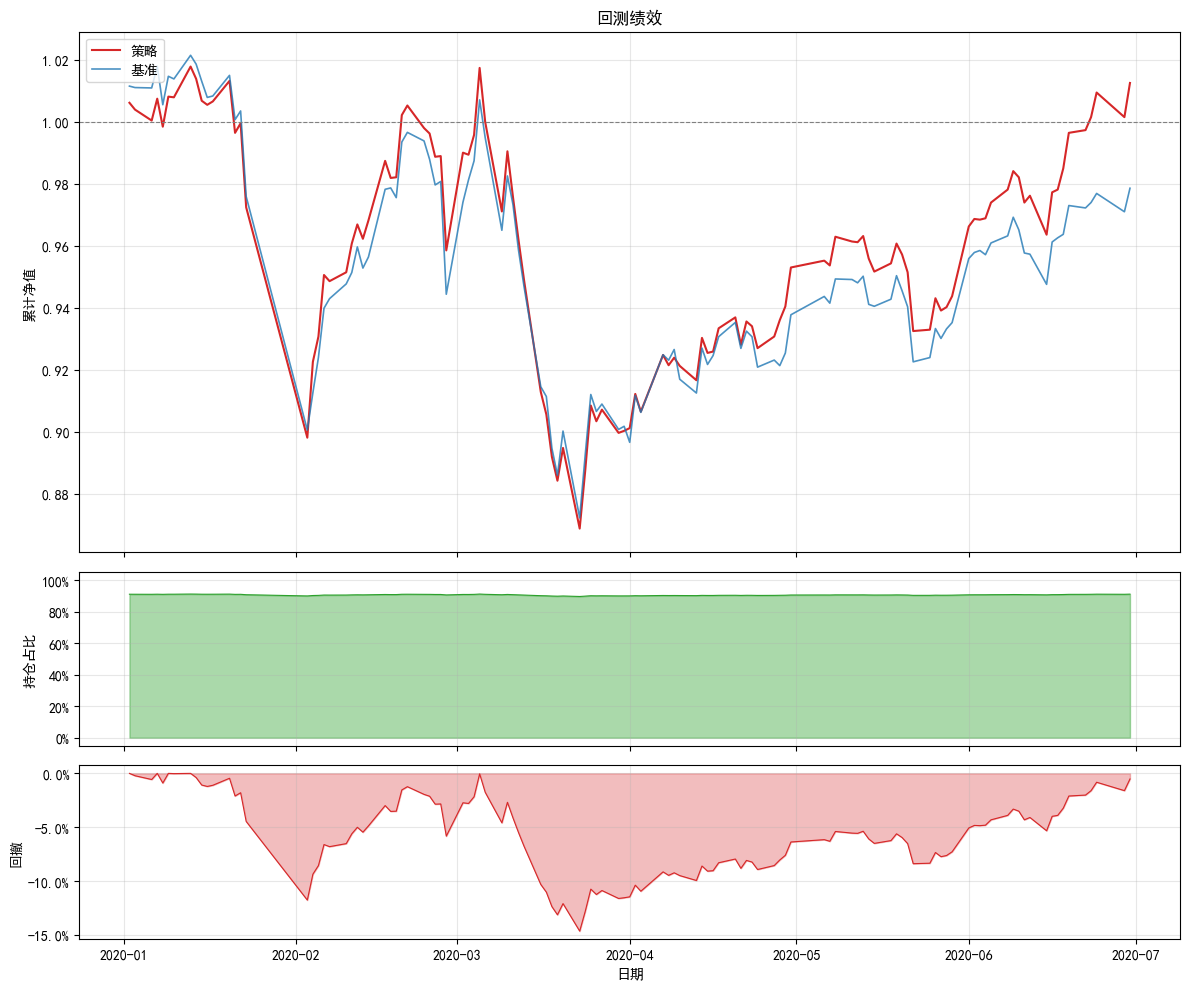

指标,值
总收益率,1.25%
年化收益率,2.72%
CAGR,2.72%
年化波动率,21.99%
最大回撤,-14.65%
夏普比率,0.2326
索提诺比率,0.2973
卡尔玛比率,0.1854
Omega,1.0447
Alpha,0.0765


Loading ITables v2.7.0 from the internet... (need help?)


Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
ctx = run_backtest(
    initialize, None,
    start_date="2020-01-02", end_date="2020-06-30",
    capital=1000000, data_path="../data",
    benchmark="000001.SH", asset_type="fund", plot=True,
)
